In [66]:
import pandas as pd
import plotly.express as px
import chart_studio.plotly as py
import cufflinks as cf
cf.go_offline(connected=True)
import missingno
import matplotlib.pyplot as plt
import numpy as np
import string

In [67]:
df = pd.read_csv('world-data-2023.csv')
df

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.50%,"912,050","343,000",17.88,58.0,Caracas,"164,175",...,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368",6.423750,-66.589730
191,Vietnam,314,VN,39.30%,"331,210","522,000",16.75,84.0,Hanoi,"192,668",...,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140",14.058324,108.277199
192,Yemen,56,YE,44.60%,"527,968","40,000",30.45,967.0,Sanaa,"10,609",...,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523",15.552727,48.516388
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332


In [68]:
drop_features = ['Abbreviation', 'Capital/Major City', 'Latitude', 'Longitude', 'Official language','Density\n(P/Km2)','Calling Code','Currency-Code']
df.drop(drop_features, axis=1, inplace=True)
df

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,58.10%,"652,230","323,000",32.49,"8,672",149.9,2.30%,4.47,2.10%,...,638.0,$0.43,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273"
1,Albania,43.10%,"28,748","9,000",11.78,"4,536",119.05,1.40%,1.62,28.10%,...,15.0,$1.12,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593"
2,Algeria,17.40%,"2,381,741","317,000",24.28,"150,006",151.36,2.00%,3.02,0.80%,...,112.0,$0.95,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
3,Andorra,40.00%,468,NaN,7.20,469,NaN,NaN,1.27,34.00%,...,NaN,$6.63,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873"
4,Angola,47.50%,"1,246,700","117,000",40.73,"34,693",261.73,17.10%,5.52,46.30%,...,241.0,$0.71,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,24.50%,"912,050","343,000",17.88,"164,175","2,740.27",254.90%,2.27,52.70%,...,125.0,$0.01,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368"
191,Vietnam,39.30%,"331,210","522,000",16.75,"192,668",163.52,2.80%,2.05,48.10%,...,43.0,$0.73,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140"
192,Yemen,44.60%,"527,968","40,000",30.45,"10,609",157.58,8.10%,3.79,1.00%,...,164.0,NaN,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523"
193,Zambia,32.10%,"752,618","16,000",36.19,"5,141",212.31,9.20%,4.63,65.20%,...,213.0,$0.24,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713"


In [69]:
df = df.dropna()

In [70]:
df['Agricultural Land( %)'] = df['Agricultural Land( %)'].str.replace('%', '').astype(float)
df['Land Area(Km2)'] = df['Land Area(Km2)'].str.replace(',', '').astype(int)
df['Armed Forces size'] = df['Armed Forces size'].str.replace(',','').astype(int)
df['Co2-Emissions'] = df['Co2-Emissions'].str.replace(',','').astype(int)
df['CPI Change (%)'] = df['CPI Change (%)'].str.replace('%', '').astype(float)
df['Forested Area (%)'] = df['Forested Area (%)'].str.replace('%','').astype(float)
df['Gasoline Price'] = df['Gasoline Price'].str.replace('$','').astype(float)
df['Gross primary education enrollment (%)'] = df['Gross primary education enrollment (%)'].str.replace('%','').astype(float)
df['Gross tertiary education enrollment (%)'] = df['Gross tertiary education enrollment (%)'].str.replace('%','').astype(float)
df['Minimum wage'] = df['Minimum wage'].str.replace('$','').astype(float)
df['Out of pocket health expenditure'].str.replace('%','').astype(float)
df['Population'] = df['Population'].str.replace(',','').astype(int)
df['Population: Labor force participation (%)'] = df['Population: Labor force participation (%)'].str.replace('%','').astype(float)
df['Tax revenue (%)'] = df['Tax revenue (%)'].str.replace('%','').astype(float)
df['Total tax rate'] = df['Total tax rate'].str.replace('%','').astype(float)
df['Unemployment rate'] = df['Unemployment rate'].str.replace('%','').astype(float)
df['Urban_population'] = df['Urban_population'].str.replace(',','').astype(int)
df

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,58.1,652230,323000,32.49,8672,149.9,2.3,4.47,2.1,...,638.0,0.43,78.40%,0.28,38041754,48.9,9.3,71.4,11.12,9797273
1,Albania,43.1,28748,9000,11.78,4536,119.05,1.4,1.62,28.1,...,15.0,1.12,56.90%,1.20,2854191,55.7,18.6,36.6,12.33,1747593
2,Algeria,17.4,2381741,317000,24.28,150006,151.36,2.0,3.02,0.8,...,112.0,0.95,28.10%,1.72,43053054,41.2,37.2,66.1,11.70,31510100
4,Angola,47.5,1246700,117000,40.73,34693,261.73,17.1,5.52,46.3,...,241.0,0.71,33.40%,0.21,31825295,77.5,9.2,49.1,6.89,21061025
6,Argentina,54.3,2780400,105000,17.02,201348,232.75,53.5,2.26,9.8,...,39.0,3.35,17.60%,3.96,44938712,61.3,10.1,106.3,9.79,41339571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,United Kingdom,71.7,243610,148000,11.00,379025,119.62,1.7,1.68,13.1,...,7.0,10.13,14.80%,2.81,66834405,62.8,25.5,30.6,3.85,55908316
186,United States,44.4,9833517,1359000,11.60,5006302,117.24,7.5,1.73,33.9,...,19.0,7.25,11.10%,2.61,328239523,62.0,9.6,36.6,14.70,270663028
187,Uruguay,82.6,176215,22000,13.86,6766,202.92,7.9,1.97,10.7,...,17.0,1.66,16.20%,5.05,3461734,64.0,20.1,41.8,8.73,3303394
191,Vietnam,39.3,331210,522000,16.75,192668,163.52,2.8,2.05,48.1,...,43.0,0.73,43.50%,0.82,96462106,77.4,19.1,37.6,2.01,35332140


In [71]:
df = df.dropna(axis=0)

<Axes: >

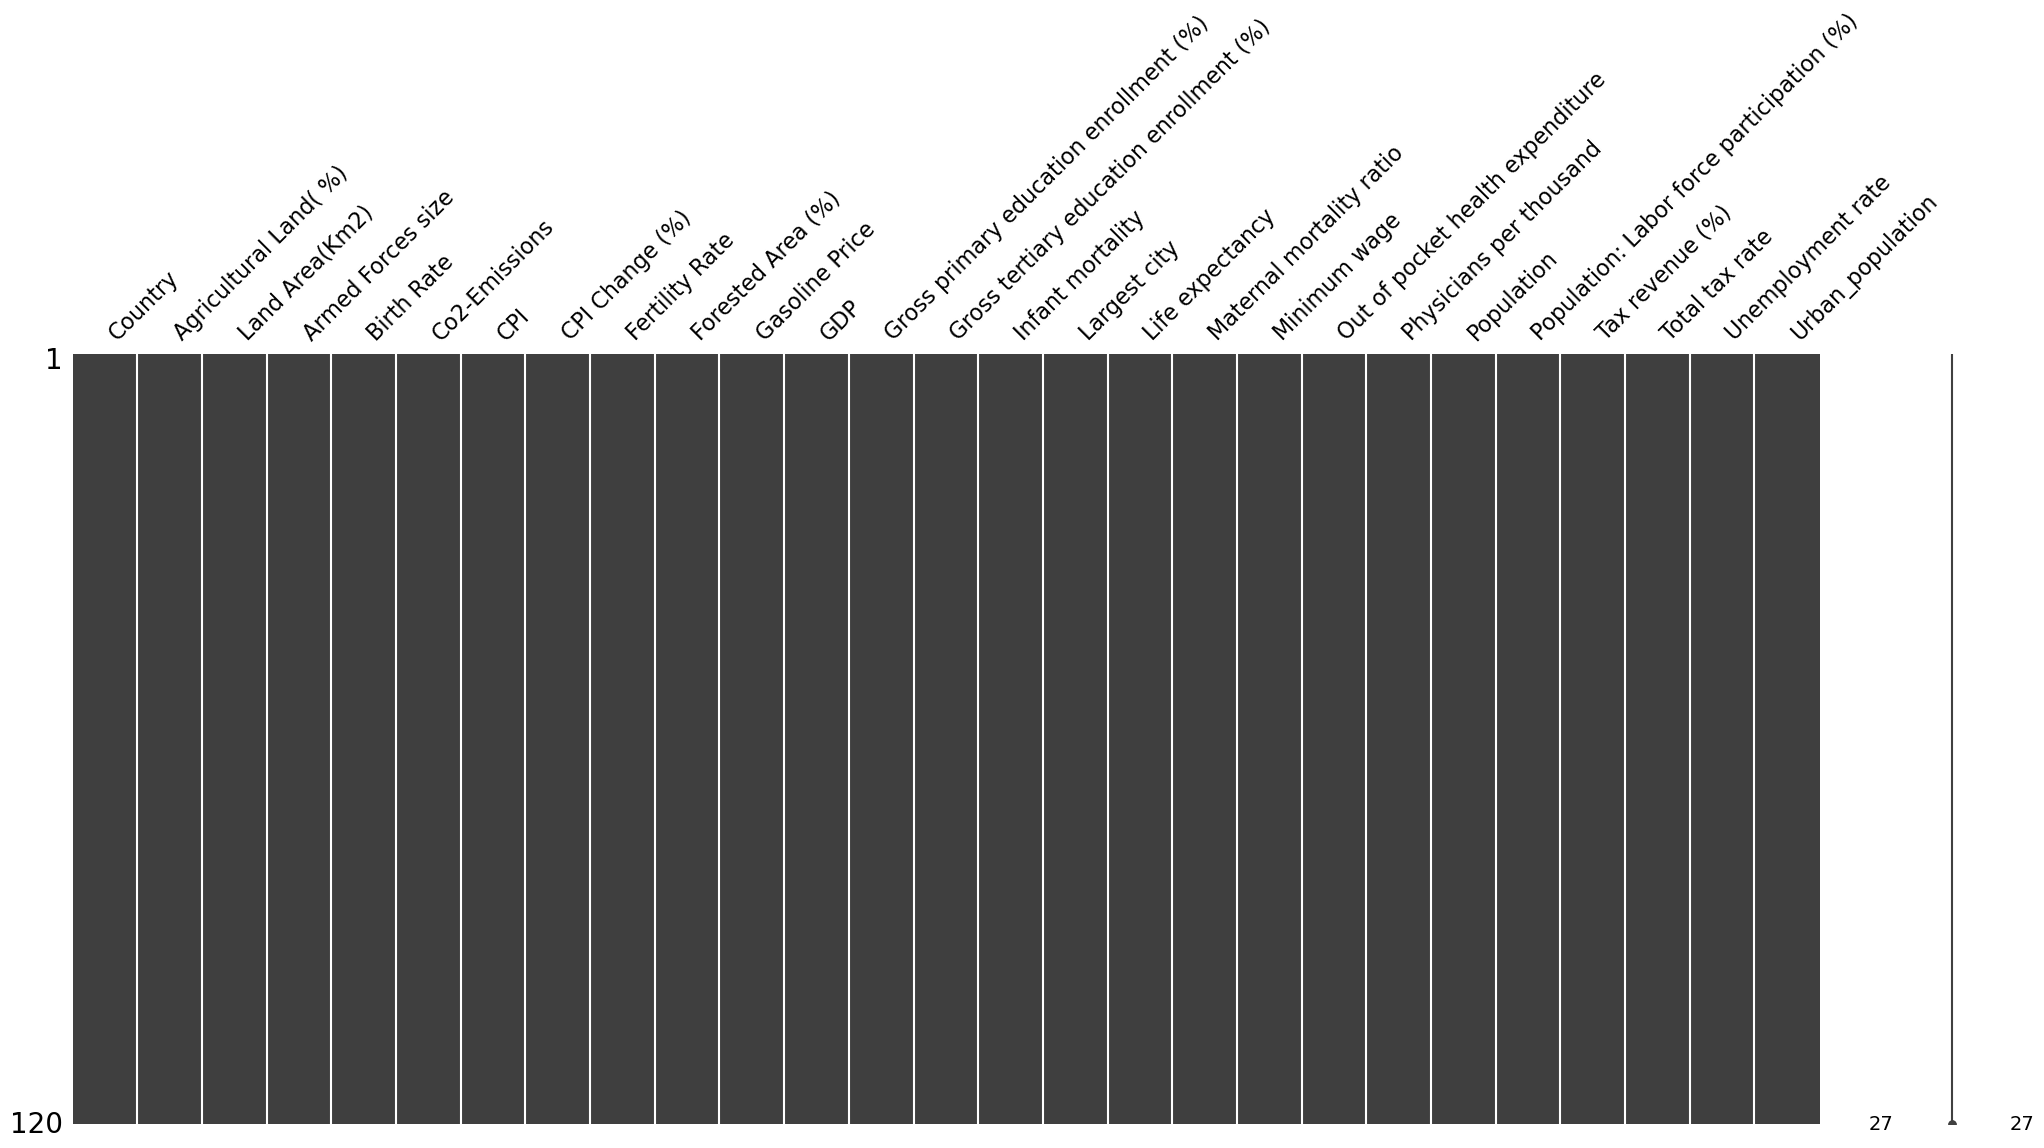

In [72]:
missingno.matrix(df)

In [73]:
df.describe()

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI Change (%),Fertility Rate,Forested Area (%),Gasoline Price,Gross primary education enrollment (%),...,Life expectancy,Maternal mortality ratio,Minimum wage,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
count,120.00000,1.200000e+02,1.200000e+02,120.000000,1.200000e+02,120.000000,120.000000,120.000000,120.000000,120.000000,...,120.000000,120.000000,120.000000,120.000000,1.200000e+02,120.000000,120.000000,120.000000,120.000000,1.200000e+02
mean,42.12750,9.713954e+05,1.859000e+05,20.239583,2.588873e+05,5.065000,2.675667,30.253333,0.980750,103.214167,...,72.459167,148.508333,2.296417,1.872167,5.755934e+07,61.998333,15.716667,40.500833,6.645000,3.225849e+07
std,20.32709,2.384977e+06,4.252590e+05,10.028579,1.041018e+06,9.024511,1.303065,21.052204,0.309166,11.675589,...,7.421256,213.802430,3.117075,1.585561,1.817313e+08,9.786519,6.501601,14.196168,4.527539,9.335375e+07
min,1.40000,3.160000e+02,1.000000e+03,6.400000,2.970000e+02,-3.200000,0.980000,0.000000,0.240000,74.700000,...,52.800000,2.000000,0.010000,0.010000,2.870250e+05,39.300000,0.000000,9.900000,0.470000,8.943100e+04
25%,27.90000,6.263800e+04,1.075000e+04,11.225000,6.175000e+03,1.400000,1.687500,11.575000,0.767500,98.950000,...,67.250000,14.500000,0.390000,0.377500,4.913280e+06,55.850000,11.475000,31.875000,3.415000,2.547689e+06
50%,43.20000,2.375955e+05,3.700000e+04,17.830000,2.407900e+04,2.650000,2.175000,31.450000,0.975000,102.550000,...,74.350000,44.000000,0.980000,1.575000,1.404876e+07,61.900000,14.950000,38.700000,5.375000,7.879434e+06
75%,56.57500,6.583170e+05,1.785000e+05,28.375000,1.208485e+05,4.825000,3.522500,43.225000,1.160000,107.525000,...,77.450000,185.250000,2.830000,3.002500,4.287319e+07,68.075000,20.100000,47.900000,8.915000,2.470441e+07
max,82.60000,1.709824e+07,3.031000e+06,46.080000,9.893038e+06,53.500000,6.910000,90.000000,1.810000,142.500000,...,84.200000,1120.000000,13.590000,7.120000,1.397715e+09,86.100000,37.200000,106.300000,23.410000,8.429340e+08


In [74]:
df.corr(numeric_only=True)

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI Change (%),Fertility Rate,Forested Area (%),Gasoline Price,Gross primary education enrollment (%),...,Life expectancy,Maternal mortality ratio,Minimum wage,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
Agricultural Land( %),1.000000,-0.094716,0.048109,0.046887,0.049251,0.051799,0.036202,-0.479528,-0.046323,0.066081,...,-0.091702,0.084137,-0.029806,0.051420,0.114330,-0.118852,0.031236,0.017467,0.067184,0.090362
Land Area(Km2),-0.094716,1.000000,0.578881,-0.115833,0.584613,0.070576,-0.100768,0.043783,-0.202044,0.005305,...,0.094704,-0.095196,0.125973,0.107889,0.428854,0.033591,-0.169455,0.155892,0.040641,0.532928
Armed Forces size,0.048109,0.578881,1.000000,-0.168143,0.780649,0.065756,-0.167841,-0.015342,-0.147226,0.039486,...,0.093522,-0.114708,-0.035772,-0.006254,0.919811,-0.118941,-0.203833,0.160193,-0.005889,0.892436
Birth Rate,0.046887,-0.115833,-0.168143,1.000000,-0.182976,0.181648,0.981658,-0.029042,-0.209935,0.073820,...,-0.867215,0.779920,-0.506853,-0.742452,-0.079044,0.247753,-0.414078,0.133590,-0.038755,-0.136104
Co2-Emissions,0.049251,0.584613,0.780649,-0.182976,1.000000,0.003278,-0.161215,-0.008080,-0.074986,-0.013564,...,0.140740,-0.123734,0.075313,0.061681,0.807754,0.004417,-0.158487,0.119886,0.004604,0.925983
CPI Change (%),0.051799,0.070576,0.065756,0.181648,0.003278,1.000000,0.158901,-0.148543,-0.041112,-0.079450,...,-0.214914,0.203222,-0.144479,-0.116968,0.032283,-0.111755,-0.252480,0.330572,0.180209,0.028532
Fertility Rate,0.036202,-0.100768,-0.167841,0.981658,-0.161215,0.158901,1.000000,-0.029249,-0.143792,-0.003266,...,-0.844924,0.789770,-0.442311,-0.677120,-0.072807,0.238205,-0.415995,0.142781,-0.060085,-0.121728
Forested Area (%),-0.479528,0.043783,-0.015342,-0.029042,-0.008080,-0.148543,-0.029249,1.000000,0.192501,0.171906,...,-0.042025,0.043882,-0.017925,-0.096430,-0.034755,0.279226,-0.051366,0.017522,-0.147384,-0.008241
Gasoline Price,-0.046323,-0.202044,-0.147226,-0.209935,-0.074986,-0.041112,-0.143792,0.192501,1.000000,-0.045120,...,0.252737,-0.088973,0.416192,0.251423,-0.067463,-0.000113,0.406204,0.073314,-0.007079,-0.072507
Gross primary education enrollment (%),0.066081,0.005305,0.039486,0.073820,-0.013564,-0.079450,-0.003266,0.171906,-0.045120,1.000000,...,-0.082414,0.030033,-0.092850,-0.158911,0.040711,0.259968,0.038067,0.126788,0.002825,0.022057


In [75]:
df.corr(numeric_only=True).iplot(kind = 'heatmap', colorscale ='Blues')

In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 

In [77]:
df_numeric = df.select_dtypes(include=[float,int])
df_numeric = df_numeric.dropna()

In [78]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

In [79]:
pca = PCA()
pca.fit(df_scaled)

PCA()

In [80]:
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)

[0.30056567 0.18865212 0.08814458 0.0633049  0.0573988  0.05136916
 0.04744501 0.03769644 0.03030246 0.02447634 0.02367872 0.01927513
 0.01600242 0.01464736 0.01053079 0.00955817 0.00843881 0.00360195
 0.0024581  0.00165646 0.00046172 0.00033491]


In [81]:
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

In [82]:
px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y = exp_var_cumul,
    labels= {'x': 'Components', 'y': 'Explained Variance'}
)